# Multiple Instance Learning

In [1]:
from mil.models import MIL_model, MLP_encoder, MeanAggergation, MaxAggergation, AttentionAggregation, GatedAttentionAggregation
from mil.training_utils import model_run, set_seed
from mil.evaluation_utils import evaluate_accuracy
from mil.CustomDataloader import CustomLoader
from mil.CellsData import CellsData

from mil import PROJECT_ROOT

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [2]:
# Set to True if you want to use original sparse matrix data, False if you want low dimensional embeddings
use_sparse_data = True


if use_sparse_data:
    INPUT_SIZE = 2000
    BAG_KEY = 'bag'
    NUM_EPOCHS = 30
else:
    INPUT_SIZE = 30
    BAG_KEY = 'bag_embed'
    NUM_EPOCHS = 30

In [3]:
train_set = CellsData(split="train")
val_set = CellsData(split="val")
test_set = CellsData(split="test")

n_bags = sum([len(el) for el in (train_set, val_set, test_set)])
print(f"The entire datatset contains {n_bags} bags.")

train_loader = CustomLoader(train_set, batchsize=20)
validation_loader = CustomLoader(val_set, batchsize=20)
test_loader = CustomLoader(test_set, batchsize=20)

The entire datatset contains 146 bags.


In [4]:
def run_evaluation(encoder: nn.Module, aggregator: nn.Module, lr: float, decay: float, plot_title: str, path_prefix: str):
    model = MIL_model(instance_encoder=encoder, bag_aggregator=aggregator)


    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=decay)

    fig, ax = plt.subplots()


    train_loss, valid_loss, best_epoch = model_run(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        save_path_prefix=path_prefix,
        ax=ax,
        plot_title=plot_title,
        sparse=use_sparse_data,
    )

    path = path_prefix + f"{best_epoch}.torch"
    model = torch.load(path, weights_only=False)
    evaluate_accuracy(model=model, dataset=test_set, bag_key = BAG_KEY, mode = 'Test')

# Mean aggregation

Epoch 1/30, Train Loss: 0.3685, Validation Loss: 0.3679
Epoch 2/30, Train Loss: 0.3408, Validation Loss: 0.3423
Epoch 3/30, Train Loss: 0.3350, Validation Loss: 0.3491
Epoch 4/30, Train Loss: 0.3346, Validation Loss: 0.3452
Epoch 5/30, Train Loss: 0.3266, Validation Loss: 0.3378
Epoch 6/30, Train Loss: 0.3138, Validation Loss: 0.3380
Epoch 7/30, Train Loss: 0.3177, Validation Loss: 0.3360
Epoch 8/30, Train Loss: 0.3113, Validation Loss: 0.3187
Epoch 9/30, Train Loss: 0.2993, Validation Loss: 0.3774
Epoch 10/30, Train Loss: 0.2850, Validation Loss: 0.3206
Epoch 11/30, Train Loss: 0.2702, Validation Loss: 0.6589
Epoch 12/30, Train Loss: 0.2895, Validation Loss: 0.3094
Epoch 13/30, Train Loss: 0.2764, Validation Loss: 0.4818
Epoch 14/30, Train Loss: 0.2545, Validation Loss: 0.3300
Epoch 15/30, Train Loss: 0.2939, Validation Loss: 0.5078
Epoch 16/30, Train Loss: 0.2454, Validation Loss: 0.6914
Epoch 17/30, Train Loss: 0.2222, Validation Loss: 0.3006
Epoch 18/30, Train Loss: 0.2323, Validat

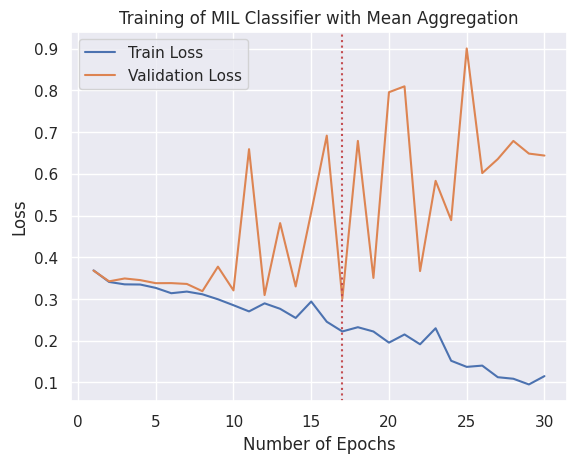

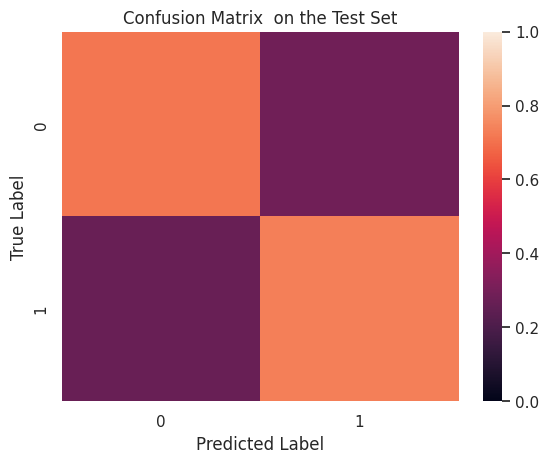

In [5]:
run_params = {}
if use_sparse_data:
    run_params = {
        "n_hidden": 3,
        "hidden_size": 10,
        "lr": 10**-2,
        "decay": 10**-2,
        "encoding_size": 10,
        "seed": 37,
    }
else:
    run_params = {
    "n_hidden": 1,
    "hidden_size": 30,
    "lr": 10**-2,
    "decay": 10**-1.7005985187830885,
    "seed": 27,
    "encoding_size": 30,
    }

set_seed(run_params["seed"])
encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"],
    hidden_size=run_params["hidden_size"],
    output_size=run_params["encoding_size"],
    input_size=INPUT_SIZE
)
aggregator = MeanAggergation(post_process=True, encoding_size=run_params["encoding_size"])

run_evaluation(
    encoder,
    aggregator,
    run_params["lr"],
    run_params["decay"],
    plot_title="Training of MIL Classifier with Mean Aggregation",
    path_prefix=str(PROJECT_ROOT / "data/torch_playground_mean_aggregation_models/epoch_")
)

## Maximum aggregation

Epoch 1/30, Train Loss: 0.3698, Validation Loss: 0.3434
Epoch 2/30, Train Loss: 0.3479, Validation Loss: 0.3419
Epoch 3/30, Train Loss: 0.3403, Validation Loss: 0.3412
Epoch 4/30, Train Loss: 0.3261, Validation Loss: 0.3476
Epoch 5/30, Train Loss: 0.3254, Validation Loss: 0.3440
Epoch 6/30, Train Loss: 0.3077, Validation Loss: 0.3451
Epoch 7/30, Train Loss: 0.2993, Validation Loss: 0.3465
Epoch 8/30, Train Loss: 0.2736, Validation Loss: 0.3317
Epoch 9/30, Train Loss: 0.2616, Validation Loss: 0.3530
Epoch 10/30, Train Loss: 0.2178, Validation Loss: 0.3317
Epoch 11/30, Train Loss: 0.1935, Validation Loss: 0.3688
Epoch 12/30, Train Loss: 0.1688, Validation Loss: 0.4380
Epoch 13/30, Train Loss: 0.1569, Validation Loss: 0.4006
Epoch 14/30, Train Loss: 0.1306, Validation Loss: 0.4671
Epoch 15/30, Train Loss: 0.1127, Validation Loss: 0.4670
Epoch 16/30, Train Loss: 0.0949, Validation Loss: 0.6596
Epoch 17/30, Train Loss: 0.0972, Validation Loss: 0.6073
Epoch 18/30, Train Loss: 0.0950, Validat

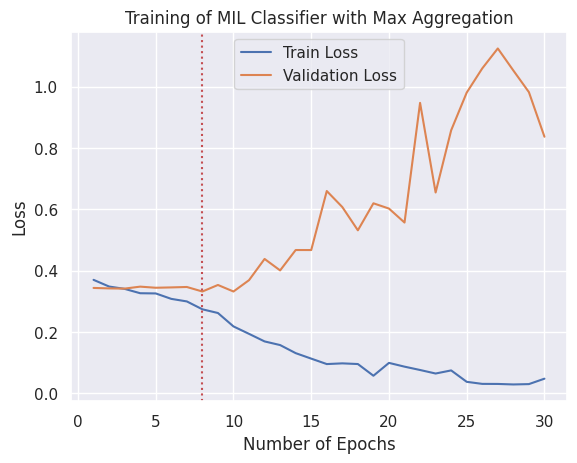

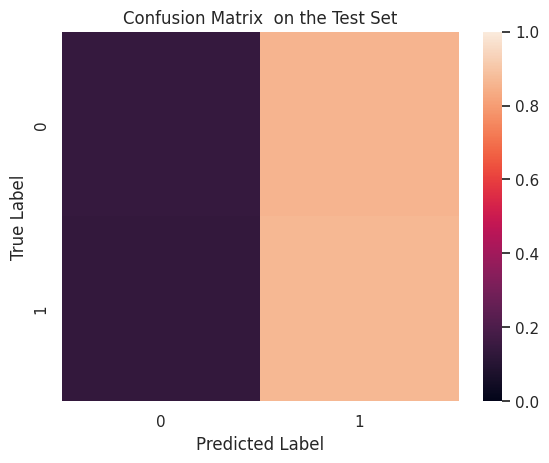

In [6]:
run_params = {}
if use_sparse_data:
    run_params = {
        "n_hidden": 3,
        "hidden_size": 10,
        "lr": 10**-2,
        "decay": 10**-2,
        "encoding_size": 10,
        "seed": 37,
    }
else:
    run_params = {
    "n_hidden": 1,
    "hidden_size": 30,
    "lr": 10**-2,
    "decay": 10**-1.7005985187830885,
    "seed": 27,
    "encoding_size": 30,
    }

set_seed(run_params["seed"])
encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"],
    hidden_size=run_params["hidden_size"],
    output_size=run_params["encoding_size"],
    input_size=INPUT_SIZE
)
aggregator = MaxAggergation(post_process=True, encoding_size=run_params["encoding_size"])

run_evaluation(
    encoder,
    aggregator,
    run_params["lr"],
    run_params["decay"],
    plot_title="Training of MIL Classifier with Max Aggregation",
    path_prefix=str(PROJECT_ROOT / "data/torch_playground_max_aggregation_models/epoch_")
)

## Attention Aggregation

Epoch 1/30, Train Loss: 0.3570, Validation Loss: 0.3460
Epoch 2/30, Train Loss: 0.3427, Validation Loss: 0.3512
Epoch 3/30, Train Loss: 0.3379, Validation Loss: 0.3452
Epoch 4/30, Train Loss: 0.3328, Validation Loss: 0.3489
Epoch 5/30, Train Loss: 0.3281, Validation Loss: 0.3555
Epoch 6/30, Train Loss: 0.3262, Validation Loss: 0.3438
Epoch 7/30, Train Loss: 0.3234, Validation Loss: 0.3514
Epoch 8/30, Train Loss: 0.3162, Validation Loss: 0.3502
Epoch 9/30, Train Loss: 0.3132, Validation Loss: 0.3445
Epoch 10/30, Train Loss: 0.3038, Validation Loss: 0.3413
Epoch 11/30, Train Loss: 0.2977, Validation Loss: 0.3435
Epoch 12/30, Train Loss: 0.2914, Validation Loss: 0.3453
Epoch 13/30, Train Loss: 0.2790, Validation Loss: 0.3232
Epoch 14/30, Train Loss: 0.2729, Validation Loss: 0.3851
Epoch 15/30, Train Loss: 0.2601, Validation Loss: 0.3680
Epoch 16/30, Train Loss: 0.2503, Validation Loss: 0.3696
Epoch 17/30, Train Loss: 0.2352, Validation Loss: 0.3948
Epoch 18/30, Train Loss: 0.2260, Validat

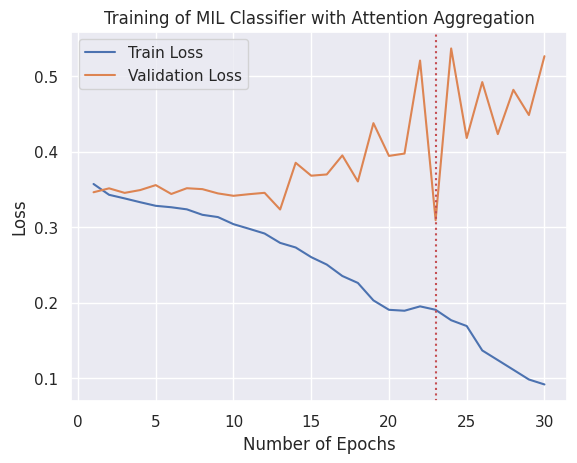

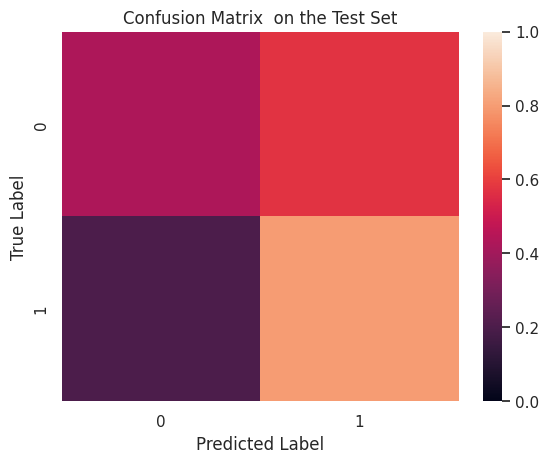

In [7]:
run_params={}

if use_sparse_data:
    run_params={
        "encoding_size": 10,
        "attention_hidden_size": 10,
        "hidden_size": 10,
        "lr": 10**-3,
        "decay": 10**-2,
        "n_hidden": 3,
        "seed": 2023,
    }
      
    
else:
    run_params={
        "encoding_size": 40,
        "attention_hidden_size": 10,
        "hidden_size": 40,
        "lr": 10**-2,
        "decay": 10**-2,
        "n_hidden": 3,
        "seed": 42,
    }

set_seed(run_params["seed"])

encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"],
    hidden_size=run_params["hidden_size"],
    output_size=run_params["encoding_size"],
    input_size=INPUT_SIZE
)
aggregator = AttentionAggregation(encoding_size=run_params["encoding_size"], attention_hidden_size=run_params["attention_hidden_size"])
run_evaluation(
    encoder,
    aggregator,
    run_params["lr"],
    run_params["decay"],
    plot_title="Training of MIL Classifier with Attention Aggregation",
    path_prefix=str(PROJECT_ROOT / "data/attention_aggregation_models/epoch_")
)

## Gated Attention Aggregation

Epoch 1/30, Train Loss: 0.5658, Validation Loss: 0.4121
Epoch 2/30, Train Loss: 0.3796, Validation Loss: 0.3423
Epoch 3/30, Train Loss: 0.3315, Validation Loss: 0.3411
Epoch 4/30, Train Loss: 0.3210, Validation Loss: 0.2834
Epoch 5/30, Train Loss: 0.3247, Validation Loss: 0.3797
Epoch 6/30, Train Loss: 0.3392, Validation Loss: 0.3227
Epoch 7/30, Train Loss: 0.3325, Validation Loss: 0.3132
Epoch 8/30, Train Loss: 0.3063, Validation Loss: 0.3461
Epoch 9/30, Train Loss: 0.3133, Validation Loss: 0.3330
Epoch 10/30, Train Loss: 0.2851, Validation Loss: 0.3170
Epoch 11/30, Train Loss: 0.2658, Validation Loss: 0.3551
Epoch 12/30, Train Loss: 0.2436, Validation Loss: 0.3264
Epoch 13/30, Train Loss: 0.2999, Validation Loss: 0.4537
Epoch 14/30, Train Loss: 0.2022, Validation Loss: 0.4017
Epoch 15/30, Train Loss: 0.1938, Validation Loss: 0.6612
Epoch 16/30, Train Loss: 0.2543, Validation Loss: 0.3789
Epoch 17/30, Train Loss: 0.2341, Validation Loss: 0.5358
Epoch 18/30, Train Loss: 0.1818, Validat

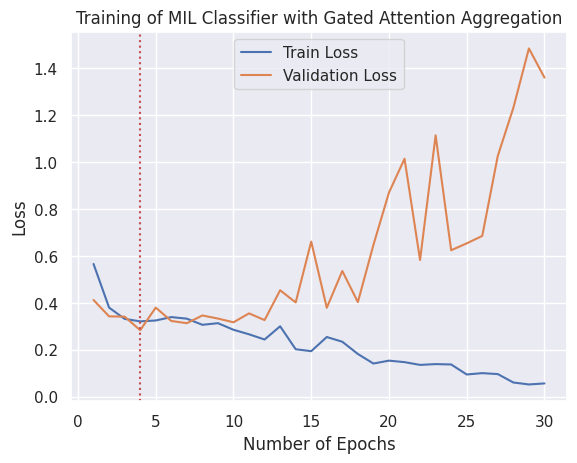

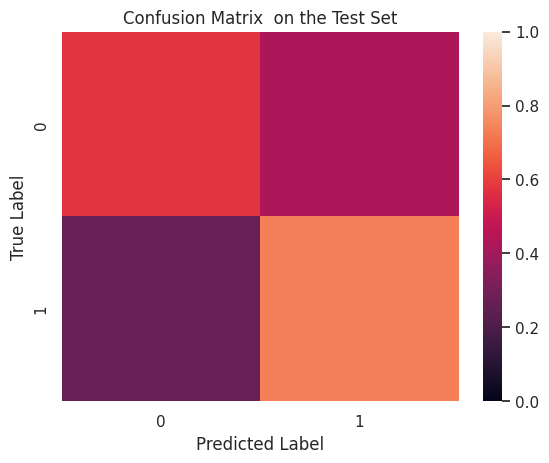

In [8]:
run_params = {}

if use_sparse_data:
    run_params = {
        "encoding_size": 10,
        "attention_hidden_size": 10,
        "hidden_size": 20,
        "lr": 10**-2,
        "decay": 10**-2,
        "n_hidden": 3,
        "seed": 0,
    }
else:
    run_params = {
        "encoding_size": 4,
        "attention_hidden_size": 42,
        "hidden_size": 43,
        "lr": 10**-2,
        "decay": 10**-2,
        "n_hidden": 2,
        "seed": 0,
    }

set_seed(run_params["seed"])
encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"],
    hidden_size=run_params["hidden_size"],
    output_size=run_params["encoding_size"],
    input_size=INPUT_SIZE
)
aggregator = GatedAttentionAggregation(
    encoding_size=run_params["encoding_size"], 
    attention_hidden_size=run_params["attention_hidden_size"]
)

run_evaluation(
    encoder,
    aggregator,
    run_params["lr"],
    run_params["decay"],
    plot_title="Training of MIL Classifier with Gated Attention Aggregation",
    path_prefix=str(PROJECT_ROOT / "data/gated_attention_aggregation_models/epoch_")
)